In [1]:
%pip install numpy pandas matplotlib statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'e:\New folder\menna ahmed khamis\after iti\Ai\Jupyter_lab\projects\5-Credit_card_fraud_detection\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
# importing the required dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

In [4]:
# load data
df = pd.read_csv("airline-passengers.csv")
print("Dataset shape:", df.shape)
display(df.head(10))
display(df.tail(10))

Dataset shape: (144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


,Month,Passengers
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [5]:
# basic dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
# check missing values
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

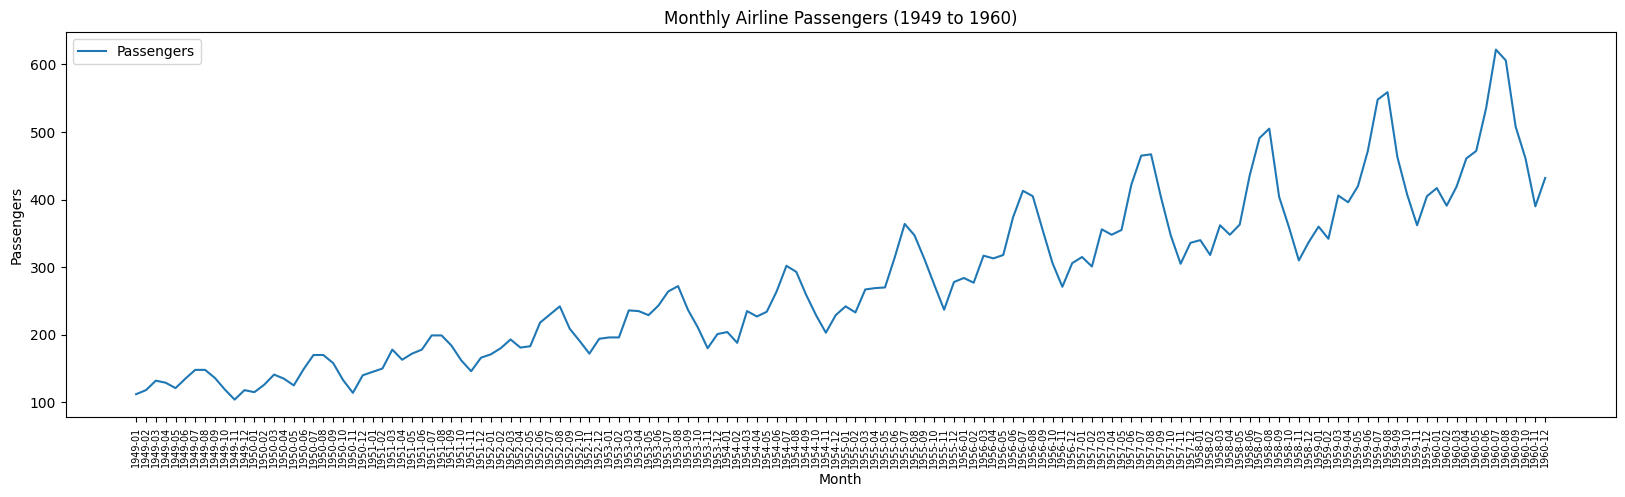

In [12]:
# plot time series
plt.figure(figsize=(20,5))
plt.plot(df["Month"], df["Passengers"], label="Passengers")
plt.title("Monthly Airline Passengers (1949 to 1960)")
plt.ylabel("Passengers")
plt.xlabel("Month")
plt.xticks(rotation="vertical",fontsize=7)

plt.legend()
plt.show()

In [13]:
# check for non-stationary (seasonal) data using Augmented Dickey-Fuller test (adfuller)
result = adfuller(df["Passengers"])
p_value = result[1]
adf_value = result[0]
print(f"p-value: {p_value:.3f}")
print(f"ADF Stat: {adf_value:.3f}")

p-value: 0.992
ADF Stat: 0.815


Null Hypothesis (H0) -> The data is non-stationary (seasonal)

Alternate Hypothesis (H1) -> The data is stationary (non-seasonal)

>Inference: The high p-value shows the series is non stationary, so transformations like differencing or decomposition are required before forecasting.

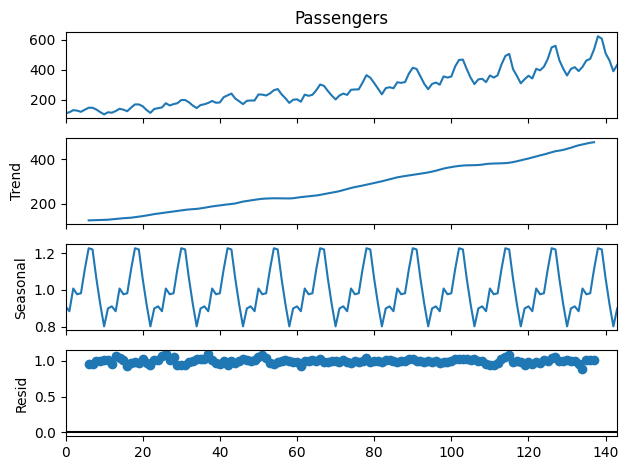

In [ ]:
decompose=seasonal_decompose(
    df["Passengers"],
    model="multiplicative",
    period=12 #12 month

)
decompose.plot()
plt.show()

In [17]:
train=df.iloc[:-12]
test=df.iloc[-12:]

In [18]:
test

,Month,Passengers
132,1960-01,417
133,1960-02,391
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461


In [19]:
# train ARIMA model
model = ARIMA(train["Passengers"], order=(5,1,0))
trained_model = model.fit()

In [20]:
forecast = trained_model.forecast(steps=12)

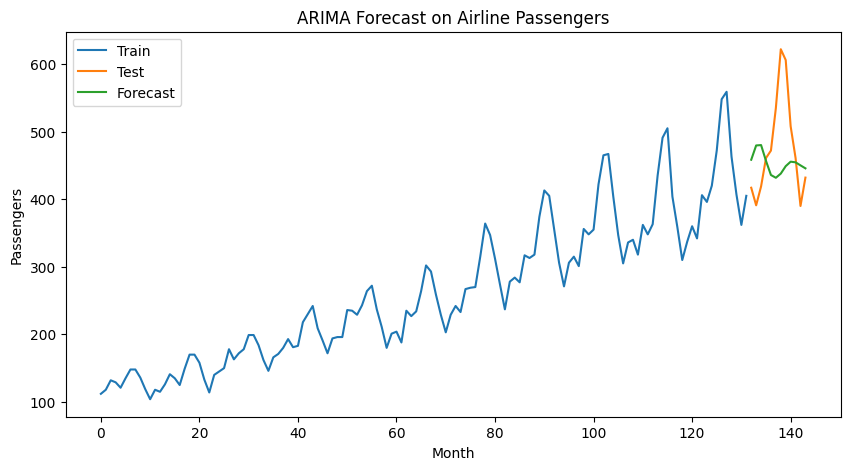

In [21]:
# plot forecast vs actual
plt.figure(figsize=(10,5))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.title("ARIMA Forecast on Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [25]:
print(df.dtypes)

Month         object
Passengers     int64
dtype: object


In [27]:
# error metric
mae = mean_absolute_error(test['Passengers'], forecast)
mse = mean_squared_error(test['Passengers'], forecast)
rmse = root_mean_squared_error(test['Passengers'], forecast)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 67.39
MSE: 7536.00
RMSE: 86.81


In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [30]:
train_log = np.log(train["Passengers"])
test_log = np.log(test["Passengers"])

In [31]:
sarimax_model = SARIMAX(
    train_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

# train the model
trained_sarimax_model = sarimax_model.fit(disp=False, maxiter=200)

In [33]:
forecast_log = trained_sarimax_model.forecast(steps=12)
forecast_sarimax = np.exp(forecast_log)

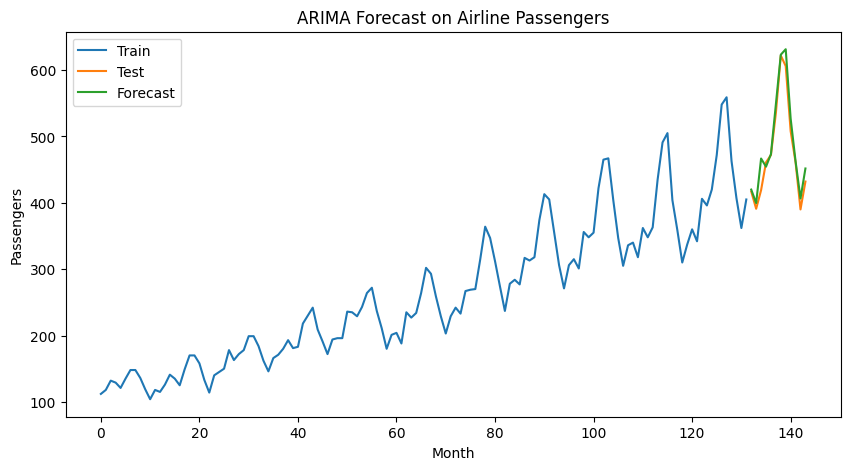

In [36]:
# plot forecast_sarimax vs actual
plt.figure(figsize=(10,5))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")
plt.plot(test.index, forecast_sarimax, label="Forecast")
plt.title("ARIMA Forecast on Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

**ARIMA**

Full form: AutoRegressive Integrated Moving Average

One-liner: Predicts future values by removing trend and learning from past values and past errors.

(P, D, Q)
- P → past values used
- D → trend removal
- Q → past errors used

⸻

**SARIMAX**

Full form: Seasonal AutoRegressive Integrated Moving Average with eXogenous variables

One-liner: ARIMA extended to learn repeating seasonal patterns and optional external inputs.

Seasonal (P, D, Q, S)
- P, D, Q → seasonal memory and corrections
- S → season length (12 for monthly data)

⸻

Quick rule
- ARIMA → no seasonality
- SARIMAX → seasonality present